In [1]:
import sys
sys.path.append('..')

import selex_dca, utils

import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

import utils
import selex_dca
import selex_distribution, energy_models, tree, data_loading, training, callback, sampling, diagnostic, tworound_potts

import pickle

import tworound_potts

/home/scrotti/Aptamer2025py/experiments/../selex_dca.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
dtype = torch.float32
device = utils.best_device()

Selected device: cuda


In [3]:
experiment_id_idx = 0
experiment_ids = ['Dop8V030', 'Dop8V930', 'Dop8V2430']
experiment_id = experiment_ids[experiment_id_idx]
round_ids = ["ARN", "R01", "R02N"]

In [4]:
sequences = []
for round_id in round_ids:
    sequences.append(utils.sequences_from_file(experiment_id, round_id))
    print(f"Finished round {round_id}")

Finished round ARN
Finished round R01
Finished round R02N


In [8]:
sequences_oh = [utils.one_hot(seq).to(dtype=dtype) for seq in sequences]

In [9]:
total_reads = torch.Tensor([s.shape[0] for s in sequences_oh]).to(device)
fi_tuple, _, _ = zip(*[utils.frequences_from_sequences_oh(s) for s in sequences_oh])
fi = torch.stack(fi_tuple)

In [12]:
tr = tree.Tree()
tr.add_node(-1, name = "R01")
tr.add_node(0, name = "R02N")

selected_modes = torch.BoolTensor(
    [[1], [1]]
)

L, q = sequences_oh[0][0].shape

k, h = training.init_from_indep_sites(sequences_oh, total_reads.cpu(), fi)
J = torch.zeros(L, q, L, q, dtype=dtype)

Ns0 = energy_models.IndepSites(k)
potts = energy_models.Potts(J, h)
# unbound = energy_models.ConstantEnergy(-10.0)

# ps = selex_distribution.MultiModeDistribution(potts, unbound)
ps = selex_distribution.MultiModeDistribution(potts, normalized=False)
model = selex_distribution.MultiRoundDistribution(Ns0, ps, tr, selected_modes).to(device)

In [13]:
batch_size = 10**6
data_loaders = [data_loading.SelexRoundDataLoader(seq_oh, batch_size=batch_size, device=device) for seq_oh in sequences_oh]
n_rounds = len(data_loaders) 

In [14]:
n_chains = 10**5
chains = training.init_chains(n_rounds, n_chains, L, q, dtype=dtype, device=device)
log_weights = torch.zeros(n_rounds, n_chains, dtype=dtype, device=device)

In [15]:
weight_decay = 0.0
lr = 0.01

optimizer = torch.optim.AdamW([
    {'params': (model.round_zero.h), 'lr': 10*lr},
    {'params': (model.selection.modes[0].J,), 'weight_decay': weight_decay},
    {'params': (model.selection.modes[0].h,)},
], lr=lr, weight_decay=0.0)

In [16]:
import importlib
# importlib.reload(utils)
# importlib.reload(selex_distribution)
# importlib.reload(energy_models)
# importlib.reload(sampling)
# importlib.reload(training)
# importlib.reload(callback)

In [18]:
checkpoint_every = 500
checkpoint_filename = 'gradient_persistence'

callbacks = [callback.ConvergenceMetricsCallback(), callback.PearsonCovarianceCallback(), 
             callback.CheckpointCallback(save_every=checkpoint_every, checkpoint_filename=checkpoint_filename),
             callback.ParamsCallback(save_every=1), callback.GradientPersistenceCallback()
            ]

In [ ]:
n_sweeps = 10
max_epochs = 10000

training.train(model, data_loaders, total_reads, chains, n_sweeps, max_epochs,
               optimizer=optimizer, callbacks=callbacks, log_weights=log_weights)

 0.00%[                                                                                                       …

In [21]:
cb_convergence, cb_pearson, cb_checkpoint, cb_params, cb_persistence = callbacks

(<Figure size 400x300 with 1 Axes>,
 <Axes: title={'center': 'Smoothed gradient persistence'}, xlabel='iter', ylabel='$\\cos(\\nabla \\log L^{(it)}, \\nabla \\log L^{(it+1)})$'>)

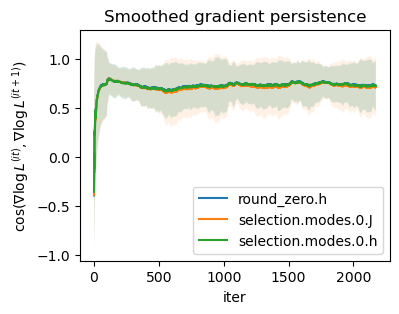

In [22]:
cb_persistence.plot()

(<Figure size 1200x300 with 4 Axes>,
 array([<Axes: xlabel='iter', ylabel='|1-pearson|'>,
        <Axes: xlabel='iter', ylabel='|1-slope|'>, <Axes: xlabel='iter'>,
        <Axes: xlabel='iter', ylabel='NLL'>], dtype=object))

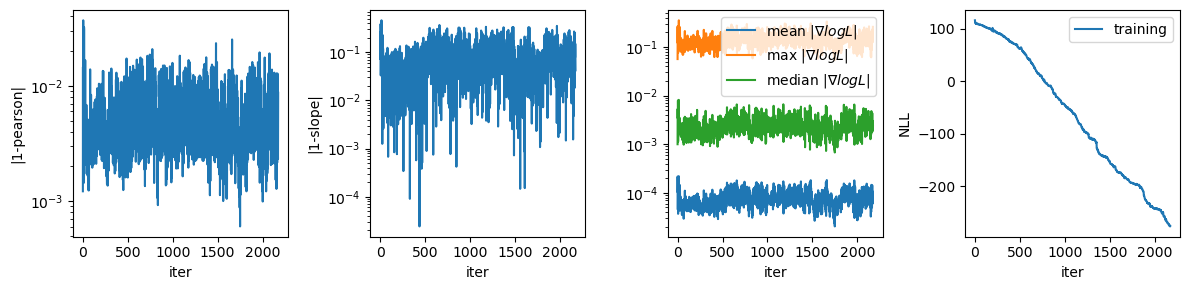

In [23]:
callbacks[0].plot()

(<Figure size 1000x300 with 1 Axes>,
 <Axes: title={'center': 'Max abs gradient'}, xlabel='iter', ylabel='$\\max |\\nabla p|$'>)

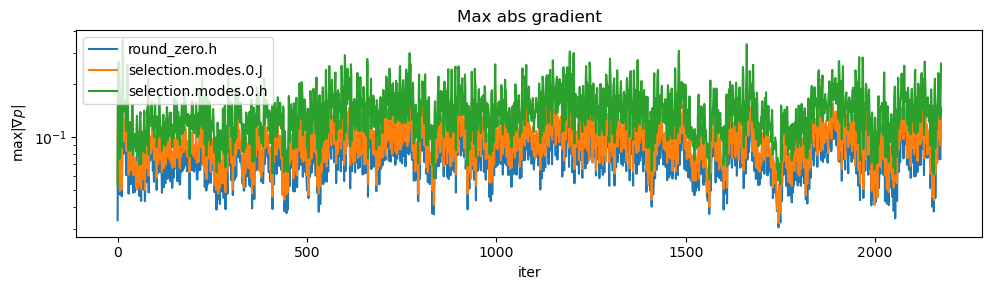

In [24]:
callbacks[0].plot_grad_detail()

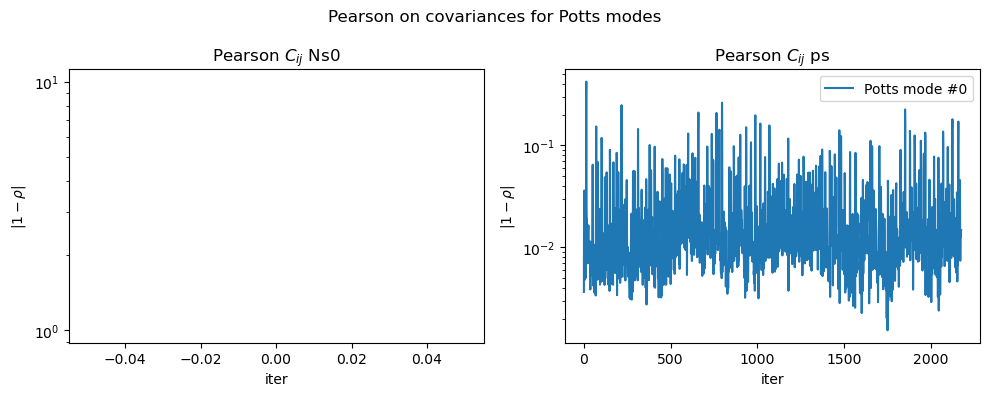

In [26]:
callbacks[1].plot();

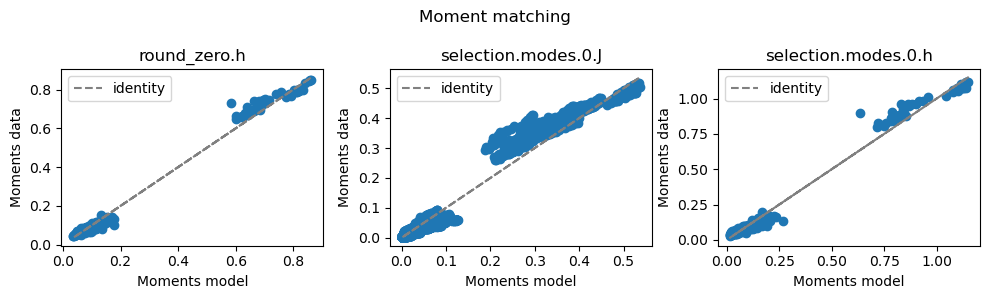

In [27]:
training.scatter_moments(model, data_loaders, chains, total_reads, figsize=(10,3));

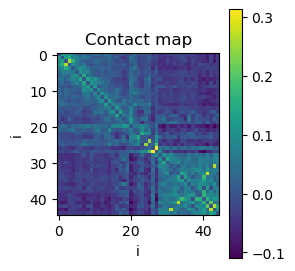

In [28]:
potts_zerosum = model.selection.modes[0].set_zerosum_gauge()
J = potts_zerosum.J.detach().cpu()
h = potts_zerosum.h.detach().cpu()

pl, ax = plt.subplots(figsize=(3,3))
F = selex_dca.get_contact_map(J)
im = ax.imshow(F)
ax.set_xlabel("i"); ax.set_ylabel("i")
plt.colorbar(im)
plt.tight_layout()
plt.title('Contact map');